## AGN Homework 7a – Fitting Spectral Energy Distributions

#### Notebook Preamble

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

### 1. AGNfitter

#### Task

- run example spectral fits
- examine and analyse results

#### Run Command
```sh
python AGNfitter/RUN_AGNfitter_multi.py AGNfitter/example/SETTINGS_AGNfitter.py
```

#### Data Preparation

In [2]:
outputs = ['3C120', 'Ark120', 'Ark564', 'Mrk493', 'Mrk876']

df = pd.DataFrame()
df['Source'] = outputs

for out in outputs:
    temp = pd.read_csv(f'outputs/{out}.txt', sep='\s+', skiprows=3)
    df.loc[df['Source'] == out, ['SFRopt', 'Lbbdered', 'AGNfrac']] = [temp['SFR_opt'][4], temp['Lbbdered(0.1-1)'][4], temp['AGNfrac(0.1-1)'][4]]

display(df)

prefix = ['SB', 'GA', 'BB', 'TO', 'TOTAL']

spec3C120, specArk120, specArk564, specMrk493, specMrk876 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

specs = [spec3C120, specArk120, specArk564, specMrk493, specMrk876]

test = pd.read_csv(f'outputs/3C120.spec', sep='\s+', skiprows=0)
spec3C120['freq'] = test['#freq']
for pre in prefix:
    cols = [f'{pre}nuLnu{i}' for i in range(10)]
    comp = test[cols].apply(pd.to_numeric, errors='coerce')
    comp = np.log10(comp.replace(0.0, np.nan))
    mean = comp.mean(axis=1)
    std = comp.std(axis=1)
    spec3C120[f'{pre}_med'] = 10**(mean)
    spec3C120[f'{pre}_lower'] = 10**(mean - std)
    spec3C120[f'{pre}_upper'] = 10**(mean + std)

test = pd.read_csv(f'outputs/Ark120.spec', sep='\s+', skiprows=0)
specArk120['freq'] = test['#freq']
for pre in prefix:
    cols = [f'{pre}nuLnu{i}' for i in range(10)]
    comp = test[cols].apply(pd.to_numeric, errors='coerce')
    comp = np.log10(comp.replace(0.0, np.nan))
    mean = comp.mean(axis=1)
    std = comp.std(axis=1)
    specArk120[f'{pre}_med'] = 10**(mean)
    specArk120[f'{pre}_lower'] = 10**(mean - std)
    specArk120[f'{pre}_upper'] = 10**(mean + std)

test = pd.read_csv(f'outputs/Ark564.spec', sep='\s+', skiprows=0)
specArk564['freq'] = test['#freq']
for pre in prefix:
    cols = [f'{pre}nuLnu{i}' for i in range(10)]
    comp = test[cols].apply(pd.to_numeric, errors='coerce')
    comp = np.log10(comp.replace(0.0, np.nan))
    mean = comp.mean(axis=1)
    std = comp.std(axis=1)
    specArk564[f'{pre}_med'] = 10**(mean)
    specArk564[f'{pre}_lower'] = 10**(mean - std)
    specArk564[f'{pre}_upper'] = 10**(mean + std)

test = pd.read_csv(f'outputs/Mrk493.spec', sep='\s+', skiprows=0)
specMrk493['freq'] = test['#freq']
for pre in prefix:
    cols = [f'{pre}nuLnu{i}' for i in range(10)]
    comp = test[cols].apply(pd.to_numeric, errors='coerce')
    comp = np.log10(comp.replace(0.0, np.nan))
    mean = comp.mean(axis=1)
    std = comp.std(axis=1)
    specMrk493[f'{pre}_med'] = 10**(mean)
    specMrk493[f'{pre}_lower'] = 10**(mean - std)
    specMrk493[f'{pre}_upper'] = 10**(mean + std)

test = pd.read_csv(f'outputs/Mrk876.spec', sep='\s+', skiprows=0)
specMrk876['freq'] = test['#freq']
for pre in prefix:
    cols = [f'{pre}nuLnu{i}' for i in range(10)]
    comp = test[cols].apply(pd.to_numeric, errors='coerce')
    comp = np.log10(comp.replace(0.0, np.nan))
    mean = comp.mean(axis=1)
    std = comp.std(axis=1)
    specMrk876[f'{pre}_med'] = 10**(mean)
    specMrk876[f'{pre}_lower'] = 10**(mean - std)
    specMrk876[f'{pre}_upper'] = 10**(mean + std)

,Source,SFRopt,Lbbdered,AGNfrac
0,3C120,25.4488,44.8716,0.9827
1,Ark120,489.2309,44.9382,0.9388
2,Ark564,29.9841,44.3507,0.7388
3,Mrk493,91.2315,44.3912,0.9100
4,Mrk876,1244.6207,45.7490,0.9523


#### Plotting Spectra

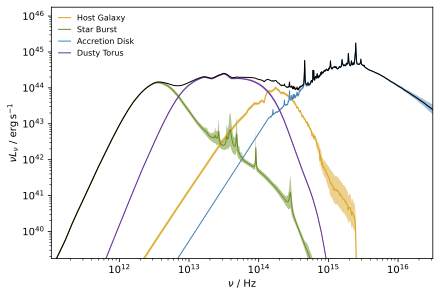

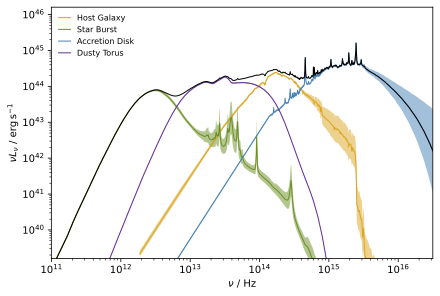

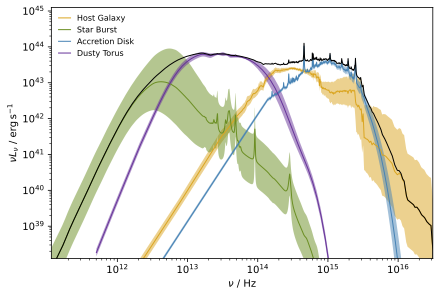

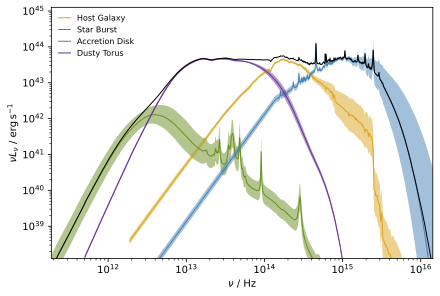

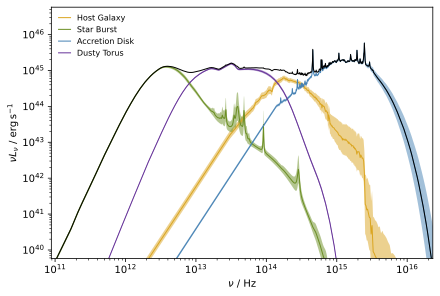

In [3]:
for spec in specs:

    f = 10**spec['freq']
    
    plt.figure(figsize=[6, 4])
    
    plt.fill_between(f, spec['GA_lower'], spec['GA_upper'], color='goldenrod', edgecolor='none', alpha=0.5)
    plt.plot(f, spec['GA_med'], color='goldenrod', linewidth=1, label='Host Galaxy')
    
    plt.fill_between(f, spec['SB_lower'], spec['SB_upper'], color='olivedrab', edgecolor='none', alpha=0.5)
    plt.plot(f, spec['SB_med'], color='olivedrab', linewidth=1, label='Star Burst')
    
    plt.fill_between(f, spec['BB_lower'], spec['BB_upper'], color='steelblue', edgecolor='none', alpha=0.5)
    plt.plot(f, spec['BB_med'], color='steelblue', linewidth=1, label='Accretion Disk')
    
    plt.fill_between(f, spec['TO_lower'], spec['TO_upper'], color='rebeccapurple', edgecolor='none', alpha=0.5)
    plt.plot(f, spec['TO_med'], color='rebeccapurple', linewidth=1, label='Dusty Torus')
    
    plt.plot(f, spec['TOTAL_med'], color='black', linewidth=1)
    
    plt.xscale('log')
    plt.yscale('log')
    
    top = max(spec['TOTAL_med']) * 1e1
    bot = max(spec['TOTAL_med']) * 1e-6
    
    left = min(f[spec['TOTAL_med'] > 0.5 * bot])
    right = max(f[spec['TOTAL_med'] > 0.5 * bot])
    
    plt.xlim(left, right)
    plt.ylim(bot, top)
    
    plt.xlabel(r'$\nu$ / Hz')
    plt.ylabel(r'$\nu L_\nu$ / erg$\,$s$^{-1}$')
    
    plt.legend(loc='upper left', ncol=1, handlelength=1.5, fontsize=8)
    
    plt.show()
    plt.close()

#### Parameter Analysis

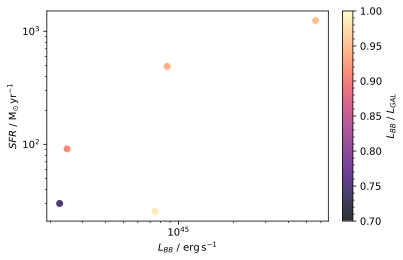

In [4]:
plt.figure(figsize=[5.5,3.5])

scatter = plt.scatter(10**df['Lbbdered'],
                      df['SFRopt'],
                      c=df['AGNfrac'],
                      cmap='magma',
                      vmin=0.7,
                      vmax=1.0,
                      alpha=0.8,
                      edgecolors='none',
                      s=50)

plt.xscale('log')
plt.yscale('log')

plt.xlim(plt.xlim())
plt.ylim(plt.ylim())

plt.xlabel(r'$L_{BB}$ / erg$\,$s$^{-1}$')
plt.ylabel(r'$SFR$ / M$_{\!\odot}$yr$^{-1}$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$L_{BB}$ / $L_{GAL}$')

plt.show()
plt.close()


- general positive correlation of central accretion disk luminosity and star formation rate
- confirms coevolution of active nuclei and starburst activity
- large amounts of infalling material feed supermassive black hole and condense into starforming regions
- outlier potential indicator of core outflow feedback radiatively blowing away matter
- also explains positive correlation between both with ratio of nucleus to host galaxy light
- outlier due to quiet state or coupling of central engine